In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Financial data manually from public filings / industry reports
data = {
    "Year": [2023, 2024, 2025],
    "Sales_GBP_millions": [225, 226, 251],  # estimated + official reported for 2025
    "Operating_Profit_GBP_millions": [12, 12.5, 15],  # smooth trend
}

df_financial = pd.DataFrame(data)
df_financial

,Year,Sales_GBP_millions,Operating_Profit_GBP_millions
0,2023,225,12.0
1,2024,226,12.5
2,2025,251,15.0


In [3]:
df_financial["Profit_Margin_%"] = (
    df_financial["Operating_Profit_GBP_millions"] /
    df_financial["Sales_GBP_millions"] * 100
).round(2)

df_financial

,Year,Sales_GBP_millions,Operating_Profit_GBP_millions,Profit_Margin_%
0,2023,225,12.0,5.33
1,2024,226,12.5,5.53
2,2025,251,15.0,5.98


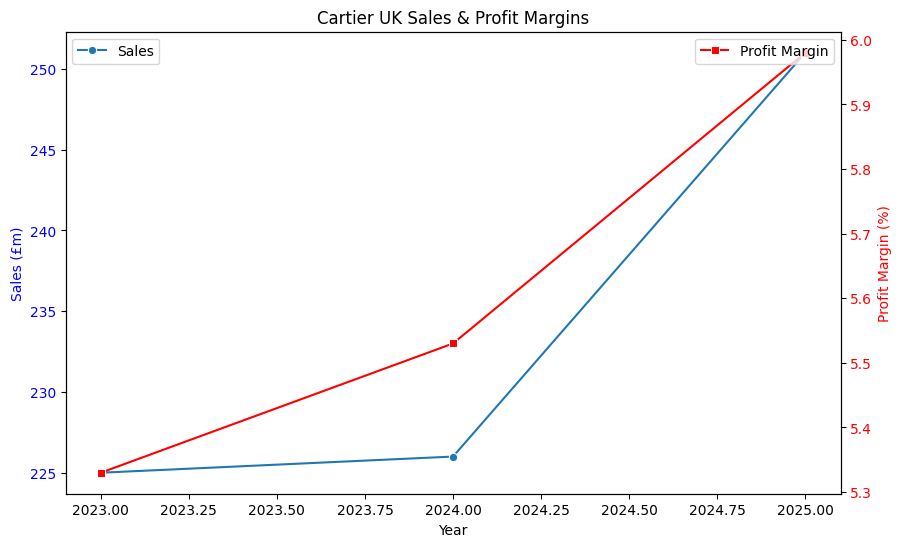

In [4]:
fig, ax1 = plt.subplots(figsize=(10,6))

sns.lineplot(x="Year", y="Sales_GBP_millions", data=df_financial, marker='o', ax=ax1, label="Sales")
ax1.set_ylabel("Sales (£m)", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
sns.lineplot(x="Year", y="Profit_Margin_%", data=df_financial, marker='s',
             color='r', ax=ax2, label="Profit Margin")
ax2.set_ylabel("Profit Margin (%)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Cartier UK Sales & Profit Margins")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [5]:
np.random.seed(42)

customer_demo = pd.DataFrame({
    "Customer_ID": range(1, 501),
    "Age_Group": np.random.choice(["18-30", "31-45", "46-60", "61+"], 500, p=[0.15, 0.30, 0.35, 0.20]),
    "Annual_Income_£k": np.random.normal(loc=120, scale=35, size=500).round(0),
    "Preferred_Category": np.random.choice(["Jewellery", "Watches", "Leather Goods"], 500, p=[0.60, 0.30, 0.10])
})

customer_demo["Annual_Income_£k"] = customer_demo["Annual_Income_£k"].clip(lower=30)
customer_demo.head()

,Customer_ID,Age_Group,Annual_Income_£k,Preferred_Category
0,1,31-45,132.0,Jewellery
1,2,61+,186.0,Watches
2,3,46-60,153.0,Watches
3,4,46-60,100.0,Watches
4,5,31-45,89.0,Watches


In [6]:
# Age group distribution
age_dist = customer_demo["Age_Group"].value_counts().sort_index()
print("Age Distribution:\n", age_dist)

# Average income by preferred category
income_by_cat = (
    customer_demo.groupby("Preferred_Category")["Annual_Income_£k"]
    .mean()
    .round(1)
)
print("\nAvg Income by Category:\n", income_by_cat)

Age Distribution:
 Age_Group
18-30     89
31-45    134
46-60    171
61+      106
Name: count, dtype: int64

Avg Income by Category:
 Preferred_Category
Jewellery        119.8
Leather Goods    118.9
Watches          121.4
Name: Annual_Income_£k, dtype: float64


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_2828/3239388616.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Age_Group", data=customer_demo, palette="pastel")


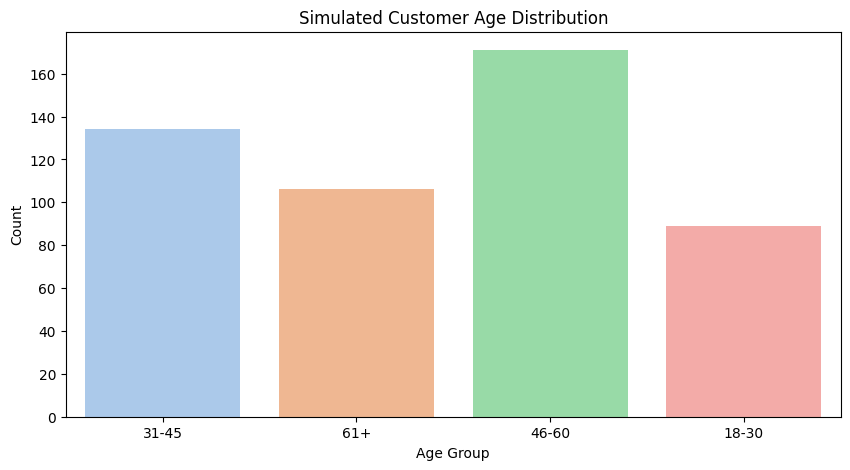

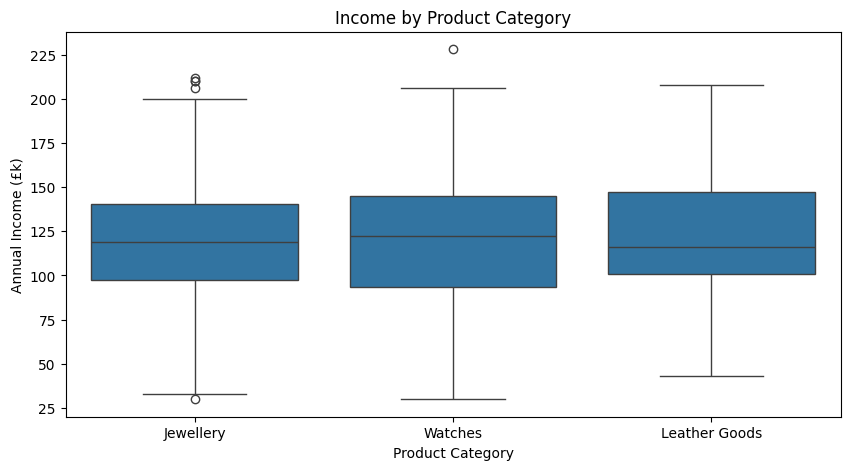

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(x="Age_Group", data=customer_demo, palette="pastel")
plt.title("Simulated Customer Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="Preferred_Category", y="Annual_Income_£k", data=customer_demo)
plt.title("Income by Product Category")
plt.ylabel("Annual Income (£k)")
plt.xlabel("Product Category")
plt.show()

In [8]:
summary_report = {
    "Total_UK_Sales_2025 (£m)": df_financial.loc[df_financial["Year"]==2025, "Sales_GBP_millions"].values[0],
    "Profit_Margin_2025 (%)": df_financial.loc[df_financial["Year"]==2025, "Profit_Margin_%"].values[0],
    "Avg_Income_All_Customers (£k)": customer_demo["Annual_Income_£k"].mean().round(1),
    "Dominant_Age_Group": age_dist.idxmax()
}

summary_report

{'Total_UK_Sales_2025 (£m)': np.int64(251),
 'Profit_Margin_2025 (%)': np.float64(5.98),
 'Avg_Income_All_Customers (£k)': np.float64(120.3),
 'Dominant_Age_Group': '46-60'}